<a href="https://colab.research.google.com/github/aesquivel94/operational-error-analyzer/blob/main/warehouse_operational_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Operational Error Analyzer**

Warehouse errors are rarely isolated. A scan failure, labeling issue, or wrong item can ripple through the workflow, creating delays, rework, and hidden operational costs. Over time, these issues impact customer satisfaction by increasing wait times, reducing service quality, and leading to incorrect orders.

This project analyzes warehouse operational errors to identify the most frequent issues, quantify their impact on operational time loss, and uncover how failures propagate across process steps.

I built this project to demonstrate how Python and data analysis can be used to identify systemic process weaknesses and turn operational friction into actionable insights that support better decision-making.

## Executive Summary

This project analyzes warehouse operational errors to uncover patterns, root causes, and opportunities for process improvement.

### Key Findings

• Scan failures act as a primary upstream driver of downstream errors.  
• Certain workflow steps concentrate a disproportionate number of issues.  
• Error chains indicate systemic process weaknesses rather than isolated failures.  

### Business Impact

The results highlight how data-driven analysis can identify critical failure points, reduce operational time loss, and improve overall process efficiency and reliability.

## Business Problem

This project analyzes warehouse operational errors to uncover patterns, root causes, and opportunities for process improvement.

### Key Findings

• Scan failures act as a primary upstream driver of downstream errors  
• Certain workflow steps concentrate a disproportionate number of issues  
• Error chains indicate systemic process weaknesses rather than isolated failures  

### Business Impact

The results highlight how data-driven analysis can identify critical failure points, reduce operational time loss, and improve overall process efficiency and reliability.

## Project Objectives

This project aims to move beyond basic error tracking and uncover how operational failures impact performance across the workflow. The analysis focuses on:

1. Identifying the most frequent operational errors  
2. Measuring which errors generate the highest operational time loss  
3. Detecting where errors occur across different workflow stages  
4. Analyzing recurring error chains and their dependencies  
5. Exploring whether errors can be predicted using available data  
6. Recommending targeted actions to improve operational efficiency  

## Dataset and Simulation Design

This project uses a synthetic dataset designed to reflect realistic warehouse operations. The data was generated to simulate common workflow stages, error types, and their potential impact on performance.

### Key Features of the Simulation

• Process-specific error probabilities to reflect differences across workflow stages.  
• Root-cause relationships between errors to simulate downstream effects.  
• Identifier types such as SKU, barcode, and LPN.  
• Estimated time impact associated with each error type.  
• Simulated error chains to model how failures propagate through the system.  

### Assumptions

The dataset is not based on real production data but is designed to approximate realistic operational behavior. The goal is to demonstrate how data analysis can be applied to identify patterns, quantify impact, and support decision-making in a warehouse environment.

## Import Packages and Setup

This section loads the required libraries and defines the default visualization style used throughout the analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visualization style for consistency across charts
sns.set_theme(style="whitegrid")

## Generate Synthetic Warehouse Error Data

This section simulates warehouse operational events, including error types, root causes, and their estimated impact on processing time.

In [2]:
# Reproducible random seed
rng = np.random.default_rng(42)

# Number of simulated events
n = 400

# -----------------------------
# Operational dimensions
# -----------------------------
shifts = ["A", "B", "C"]
process_steps = ["receiving", "picking", "packing", "back_to_stock"]

# -----------------------------
# Error probabilities by process step
# -----------------------------
step_error_weights = {
    "receiving": {
        "scan_failure": 0.35,
        "damage": 0.30,
        "lpn_error": 0.25,
        "missing_item": 0.10,
    },
    "picking": {
        "wrong_item": 0.35,
        "missing_item": 0.30,
        "lpn_error": 0.20,
        "scan_failure": 0.15,
    },
    "packing": {
        "wrong_item": 0.30,
        "damage": 0.25,
        "scan_failure": 0.25,
        "missing_item": 0.20,
    },
    "back_to_stock": {
        "missing_item": 0.35,
        "lpn_error": 0.30,
        "scan_failure": 0.20,
        "wrong_item": 0.15,
    },
}

# -----------------------------
# Error mappings
# -----------------------------
error_to_root = {
    "wrong_item": ["incorrect_location", "training_gap", "mislabel"],
    "missing_item": ["inventory_mismatch", "incorrect_location", "system_lag"],
    "scan_failure": ["damaged_label", "system_lag", "mislabel"],
    "lpn_error": ["mislabel", "system_lag", "training_gap"],
    "damage": ["training_gap", "incorrect_location", "damaged_label"],
}

error_to_identifier = {
    "wrong_item": ["sku", "barcode"],
    "missing_item": ["sku", "lpn"],
    "scan_failure": ["barcode", "lpn"],
    "lpn_error": ["lpn"],
    "damage": ["barcode", "sku"],
}

# -----------------------------
# Helper function
# -----------------------------
def weighted_choice(options_dict):
    """Sample a key based on defined probabilities."""
    options = list(options_dict.keys())
    probs = list(options_dict.values())
    return rng.choice(options, p=probs)

# -----------------------------
# Generate dates
# -----------------------------
start = np.datetime64("2025-01-01")
dates = start + rng.integers(0, 90, size=n).astype("timedelta64[D]")

rows = []

# -----------------------------
# Simulate operational events
# -----------------------------
for i in range(n):

    # Operational context
    shift = rng.choice(shifts, p=[0.36, 0.34, 0.30])
    step = rng.choice(process_steps, p=[0.20, 0.35, 0.25, 0.20])

    # Error characteristics
    error_type = weighted_choice(step_error_weights[step])
    root_cause = rng.choice(error_to_root[error_type])
    identifier_type = rng.choice(error_to_identifier[error_type])

    # Estimated operational impact
    base = rng.gamma(shape=2.0, scale=7.0)

    multiplier = {
        "missing_item": 1.4,
        "wrong_item": 1.3,
        "lpn_error": 1.2,
        "scan_failure": 1.0,
        "damage": 1.1,
    }[error_type]

    impact_minutes = int(round(base * multiplier))

    rows.append([
        str(dates[i]),
        shift,
        step,
        error_type,
        root_cause,
        identifier_type,
        impact_minutes
    ])

# -----------------------------
# Final dataset
# -----------------------------
df = pd.DataFrame(rows, columns=[
    "date",
    "shift",
    "process_step",
    "error_type",
    "root_cause",
    "identifier_type",
    "impact_minutes"
])

df.head()

,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes
0,2025-01-09,C,back_to_stock,lpn_error,system_lag,lpn,18
1,2025-03-11,A,packing,wrong_item,incorrect_location,sku,7
2,2025-02-28,A,back_to_stock,scan_failure,system_lag,barcode,12
3,2025-02-09,C,picking,wrong_item,mislabel,sku,22
4,2025-02-08,A,back_to_stock,missing_item,incorrect_location,lpn,19


## Data Validation and Quality Check

This section verifies the structure, data types, and consistency of the dataset, ensuring that all variables are correctly generated and suitable for analysis.

In [27]:
print("🔹 Preview of dataset")
display(df.head())

print("\n🔹 Dataset structure")
df.info()

print("\n🔹 Summary statistics")
display(df.describe())

print("\n🔹 Missing values")
display(df.isnull().sum())

print("\n🔹 Frequency error type")
df["error_type"].value_counts()

🔹 Preview of dataset


,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes,previous_error,error_cost,risk_score
0,2025-01-09,C,back_to_stock,lpn_error,system_lag,lpn,18,scan_failure,6.0,10.0
1,2025-03-11,A,packing,wrong_item,incorrect_location,sku,7,scan_failure,5.0,9.0
2,2025-02-28,A,back_to_stock,scan_failure,system_lag,barcode,12,no_previous,4.0,4.0
3,2025-02-09,C,picking,wrong_item,mislabel,sku,22,missing_item,5.0,13.0
4,2025-02-08,A,back_to_stock,missing_item,incorrect_location,lpn,19,scan_failure,8.0,12.0



🔹 Dataset structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             400 non-null    object 
 1   shift            400 non-null    object 
 2   process_step     400 non-null    object 
 3   error_type       400 non-null    object 
 4   root_cause       400 non-null    object 
 5   identifier_type  400 non-null    object 
 6   impact_minutes   400 non-null    int64  
 7   previous_error   400 non-null    object 
 8   error_cost       351 non-null    float64
 9   risk_score       351 non-null    float64
dtypes: float64(2), int64(1), object(7)
memory usage: 31.4+ KB

🔹 Summary statistics


,impact_minutes,error_cost,risk_score
count,400.000000,351.000000,351.000000
mean,17.162500,5.760684,9.444444
std,12.176278,1.532409,3.500476
min,1.000000,4.000000,4.000000
25%,8.750000,4.000000,4.000000
50%,15.000000,5.000000,10.000000
75%,23.000000,8.000000,12.000000
max,75.000000,8.000000,14.000000



🔹 Missing values


,0
date,0
shift,0
process_step,0
error_type,0
root_cause,0
identifier_type,0
impact_minutes,0
previous_error,0
error_cost,49
risk_score,49



🔹 Frequency error type


,count
error_type,
missing_item,96
wrong_item,94
scan_failure,91
lpn_error,70
damage,49


### Validation Notes

The dataset is well-structured and suitable for analysis:

• All core operational variables are complete, with no missing values  
• Error types are relatively balanced across categories, supporting meaningful comparisons  
• Missing values were identified in `error_cost` and `risk_score`, caused by events without a prior error  

To ensure consistency, missing values in these fields were replaced with 0, representing cases where no additional cost or risk was generated.

This preprocessing step ensures that the dataset is complete and reliable for further analysis and modeling.

In [28]:
df["error_cost"] = df["error_cost"].fillna(0)
df["risk_score"] = df["risk_score"].fillna(0)

## Error Frequency Analysis

### Question
**Which operational errors occur most frequently?**

This section identifies the most common error types, providing an initial view of where operational issues are concentrated.

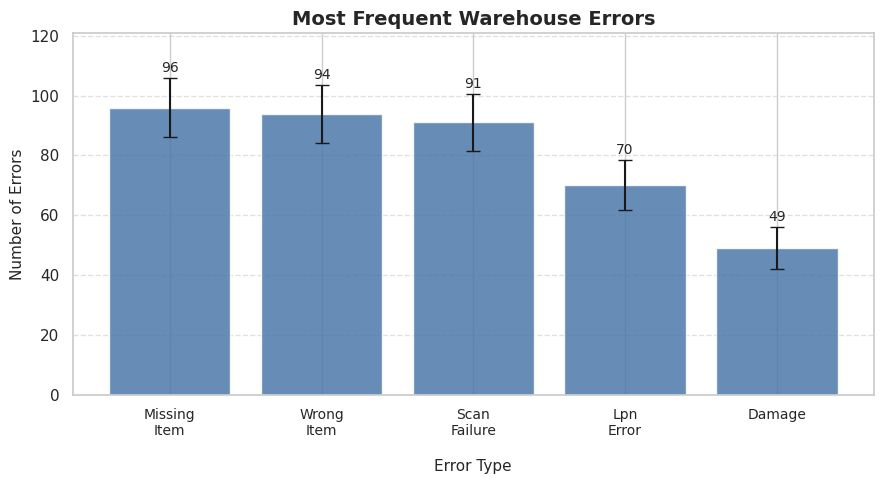

In [33]:
error_counts = df["error_type"].value_counts()

def format_label(text):
    words = text.replace("_", " ").title().split()

    if len(words) == 2:
        return f"{words[0]}\n{words[1]}"

    return "\n".join(words)

labels = [format_label(x) for x in error_counts.index]
error = np.sqrt(error_counts.values)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    labels,
    error_counts.values,
    yerr=error,
    capsize=5,
    color="#4C78A8",   # colorblind-friendly blue
    alpha=0.85
)

# Add value labels above the error bars
for i, v in enumerate(error_counts.values):
    plt.text(
        i,
        v + error[i] + 2,   # bar height + error bar + padding
        str(v),
        ha="center",
        fontsize=10
    )

plt.title("Most Frequent Warehouse Errors", fontsize=14, weight="bold")
plt.ylabel("Number of Errors", fontsize=11)
plt.xlabel("Error Type", fontsize=11, labelpad=15)
plt.xticks(fontsize=10)

plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.ylim(0, max(error_counts.values + error) + 15)
plt.tight_layout()
plt.show()

### Key Insight

The most frequent errors — **missing_item**, **wrong_item**, and **scan_failure** — highlight that both item identification and handling stages are key sources of operational issues.

The relatively balanced distribution across error types suggests that inefficiencies are systemic, rather than driven by a single point of failure, indicating the need for process-level improvements.

In [35]:
total_errors = len(df)
total_minutes = df["impact_minutes"].sum()

top_error = (
    df["error_type"]
    .value_counts()
    .idxmax()
    .replace("_", " ")
    .title()
)

top_impact = (
    df.groupby("error_type")["impact_minutes"]
    .sum()
    .idxmax()
    .replace("_", " ")
    .title()
)

print("🔹 Operational Summary\n")

print(f"Total Errors: {total_errors}")
print(f"Total Minutes Lost: {total_minutes:,}")
print(f"Most Frequent Error: {top_error}")
print(f"Highest-Impact Error: {top_impact}")

🔹 Operational Summary

Total Errors: 400
Total Minutes Lost: 6,865
Most Frequent Error: Missing Item
Highest-Impact Error: Missing Item


The same error type (**Missing Item**) is both the most frequent and the highest-impact, indicating a critical area for operational improvement.

This suggests that addressing this specific issue could significantly reduce both error volume and operational time loss.

## Errors by Process Step

### Question
**Where do operational errors occur within the workflow?**

This section analyzes how different error types are distributed across process steps to identify where failures are most likely to occur.

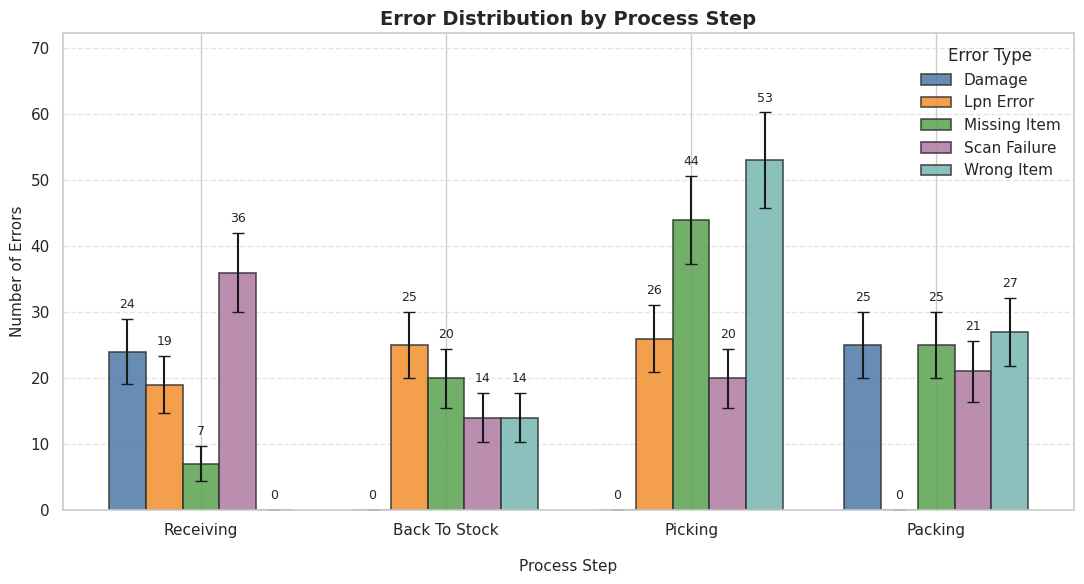

In [38]:
# Second Analysis: Errors by Process Step
step_errors = pd.crosstab(df["process_step"], df["error_type"])

# Force process order
process_order = ["receiving", "back_to_stock", "picking", "packing"]
step_errors = step_errors.loc[process_order]

# Format labels
x_labels = [x.replace("_", " ").title() for x in step_errors.index]
legend_labels = [x.replace("_", " ").title() for x in step_errors.columns]

# Colorblind-friendly palette (Okabe-Ito inspired)
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#B07AA1", "#76B7B2"]
plt.figure(figsize=(11, 6))

x = np.arange(len(step_errors.index))
width = 0.15

for i, col in enumerate(step_errors.columns):
    values = step_errors[col].values
    errors = np.sqrt(values)  # simple count-based approximation

    bars = plt.bar(
        x + i * width,
        values,
        width=width,
        yerr=errors,
        capsize=4,
        label=legend_labels[i],
        color=colors[i],
        alpha=0.85,
        edgecolor="#333333",
        linewidth=1.2
    )

    # Add value labels above the error bars
    for j, v in enumerate(values):
        plt.text(
            x[j] + i * width,
            v + errors[j] + 1.2,
            str(v),
            ha="center",
            va="bottom",
            fontsize=9
        )

# Center x tick labels
plt.xticks(
    x + width * (len(step_errors.columns) - 1) / 2,
    x_labels
)

plt.title("Error Distribution by Process Step", fontsize=14, weight="bold")
plt.ylabel("Number of Errors", fontsize=11)
plt.xlabel("Process Step", fontsize=11, labelpad=15)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Error Type", frameon=False)

# Add top space so labels don't get cramped
plt.ylim(0, (step_errors.values.max() + np.sqrt(step_errors.values.max()) + 12))

plt.tight_layout()
plt.show()

### Key Insight

Errors are not evenly distributed across the workflow. The **picking** stage stands out as the most error-prone step, with a high concentration of **wrong_item** and **missing_item** issues.

In contrast, earlier stages such as **receiving** show a different pattern, with more **scan_failure** and **damage** errors, suggesting that different process steps face distinct operational challenges.

### Focus Area

The **picking** process generates the highest number of **wrong_item** errors, making it a critical point for targeted improvement.

Since picking directly affects order accuracy, failures at this stage are more likely to propagate downstream and impact customer satisfaction.

## Operational Time Lost by Error Type

Question answered - Which operational errors generate the greatest time loss?

Error frequency alone does not fully describe operational impact.
Some errors occur less frequently but result in longer recovery time, additional handling, or workflow disruptions.

This analysis estimates the total operational time lost per error type in order to identify the most costly failures in the process.

Because frequency ≠ impact.

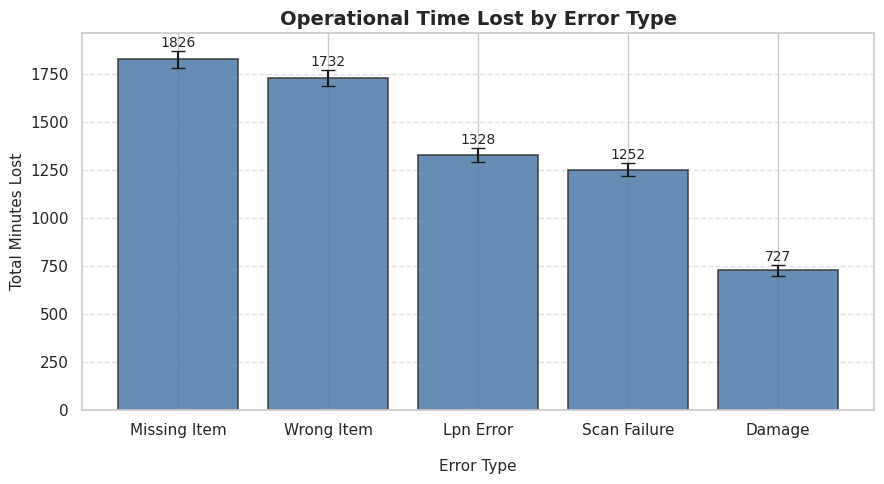

In [37]:

cost_analysis = (
    df.groupby("error_type")["impact_minutes"]
    .sum()
    .sort_values(ascending=False)
)

# Format labels
labels = [x.replace("_", " ").title() for x in cost_analysis.index]

# Error bars (simple approximation)
error = np.sqrt(cost_analysis.values)

plt.figure(figsize=(9,5))

bars = plt.bar(
    labels,
    cost_analysis.values,
    yerr=error,
    capsize=5,
    color="#4E79A7",   # colorblind-friendly
    alpha=0.85,
    edgecolor="#333333",
    linewidth=1.2
)

# Value labels above error bars
for i, v in enumerate(cost_analysis.values):
    plt.text(
        i,
        v + error[i] + 20,
        str(v),
        ha="center",
        fontsize=10
    )

plt.title("Operational Time Lost by Error Type", fontsize=14, weight="bold")
plt.ylabel("Total Minutes Lost", fontsize=11)
plt.xlabel("Error Type", fontsize=11, labelpad=15)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Simulating Error Propagation

What goes here:

previous_error logic
explanation that chains are simulated to model downstream failure patterns

Why this matters:
Separate this from the analysis.
Right now it is mixed into the middle.
It should become its own clear setup step.

## Recurring Error Chain Analysis
Question answered:
Which operational errors tend to trigger other errors?

Operational failures rarely occur in isolation.
One process breakdown can propagate downstream and generate additional errors.

This analysis identifies recurring error chains, helping reveal systemic weaknesses in the workflow.

Understanding these patterns allows operations teams to target root causes instead of isolated symptoms.

In [8]:
# Create a simple previous_error column to simulate error chains
possible_previous = {
    "wrong_item": {
        "scan_failure": 0.5,
        "lpn_error": 0.3,
        "missing_item": 0.2
    },
    "missing_item": {
        "wrong_item": 0.4,
        "scan_failure": 0.4,
        "lpn_error": 0.2
    },
    "lpn_error": {
        "scan_failure": 0.6,
        "wrong_item": 0.4
    },
    "scan_failure": {
        "no_previous": 1.0
    }
}

def sample_previous_error(x):
    options = possible_previous.get(x, {"no_previous": 1.0})

    errors = list(options.keys())
    probs = list(options.values())

    return rng.choice(errors, p=probs)

# print(df["error_type"].unique())
# missing_keys = set(df["error_type"].unique()) - set(possible_previous.keys())
# print(missing_keys)

df["previous_error"] = df["error_type"].apply(sample_previous_error)
df.head()


,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes,previous_error
0,2025-01-09,C,back_to_stock,lpn_error,system_lag,lpn,18,scan_failure
1,2025-03-11,A,packing,wrong_item,incorrect_location,sku,7,scan_failure
2,2025-02-28,A,back_to_stock,scan_failure,system_lag,barcode,12,no_previous
3,2025-02-09,C,picking,wrong_item,mislabel,sku,22,missing_item
4,2025-02-08,A,back_to_stock,missing_item,incorrect_location,lpn,19,scan_failure


In [9]:
# Save Dataset
os.makedirs("../data", exist_ok=True)

df.to_csv("../data/bts_errors.csv", index=False)
print("Saved:", df.shape)

Saved: (400, 8)


In [10]:
chain_counts = (
    df.groupby(["previous_error", "error_type"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

sankey_data = chain_counts.head(12).copy()
chain_counts.head(10)

,previous_error,error_type,count
4,no_previous,scan_failure,91
3,no_previous,damage,49
5,scan_failure,lpn_error,46
7,scan_failure,wrong_item,41
6,scan_failure,missing_item,38
9,wrong_item,missing_item,35
1,lpn_error,wrong_item,32
8,wrong_item,lpn_error,24
0,lpn_error,missing_item,23
2,missing_item,wrong_item,21


## Error Transition Matrix

Question answered:
How likely is one error to be followed by another?

What goes here:

transition matrix creation
heatmap
short interpretation

Why this matters:
This makes your notebook feel more like data science, not just reporting.

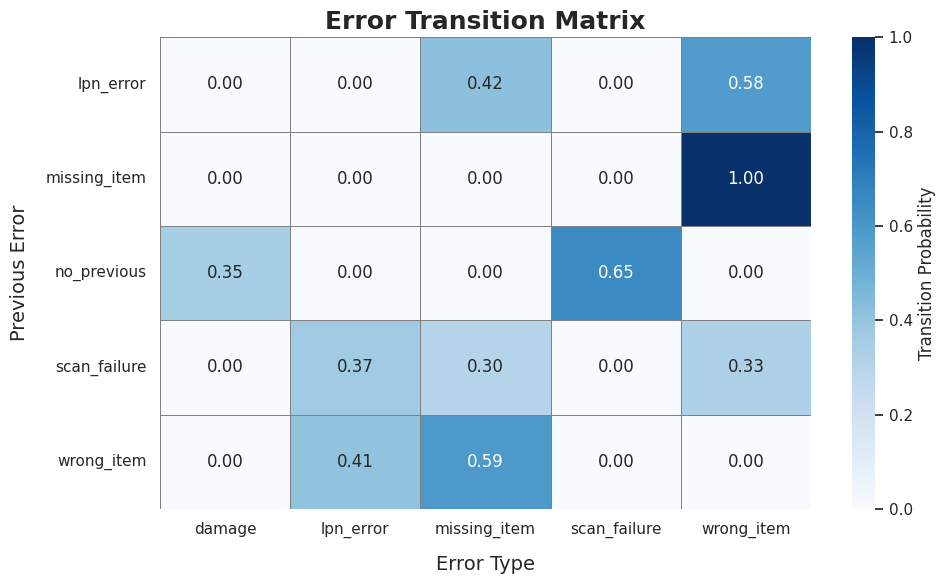

In [11]:
transition_matrix = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .unstack(fill_value=0)
)

transition_matrix = transition_matrix.div(
    transition_matrix.sum(axis=1),
    axis=0
)

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    transition_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Transition Probability"},
    ax=ax
)

ax.set_title("Error Transition Matrix", fontsize=18, weight="bold")
ax.set_xlabel("Error Type", fontsize=14, labelpad=12)
ax.set_ylabel("Previous Error", fontsize=14, labelpad=12)

ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()
plt.show()

## Visualizing Error Propagation with a Sankey Diagram
What goes here:

sankey chart
short business interpretation

Why this matters:
This is your “wow, keep reading” section.

In [12]:
# -----------------------------
# Sankey diagram of error flows
# -----------------------------
# This visualization shows how one error can lead to another,
# making downstream failure patterns easier to understand.

import plotly.graph_objects as go

# Use the most frequent chains for a clearer diagram
sankey_data = chain_counts.head(12).copy()

# Create labels for all unique nodes
all_nodes = pd.unique(
    sankey_data[["previous_error", "error_type"]].values.ravel()
)

# Format node labels for display
node_labels = [x.replace("_", " ").title() for x in all_nodes]

# Map each node name to an index
node_index = {node: i for i, node in enumerate(all_nodes)}

# Create source-target links
sources = sankey_data["previous_error"].map(node_index)
targets = sankey_data["error_type"].map(node_index)
values = sankey_data["count"]

# Build Sankey figure
fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color="#4E79A7"
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color="rgba(78, 121, 167, 0.35)"
    )
)])

fig.update_layout(
    title_text="Flow of Recurring Warehouse Error Chains",
    font=dict(size=11),
    height=500
)

fig.show()

## Top Error-to-Error Sequences

To better understand how failures move through the workflow, a Sankey diagram is used to represent recurring error chains.

This helps highlight which upstream problems are most likely to contribute to downstream operational failures.


What goes here:

horizontal bar chart of top chains
short interpretation

Why this matters:
This supports the Sankey with a clearer ranked view.

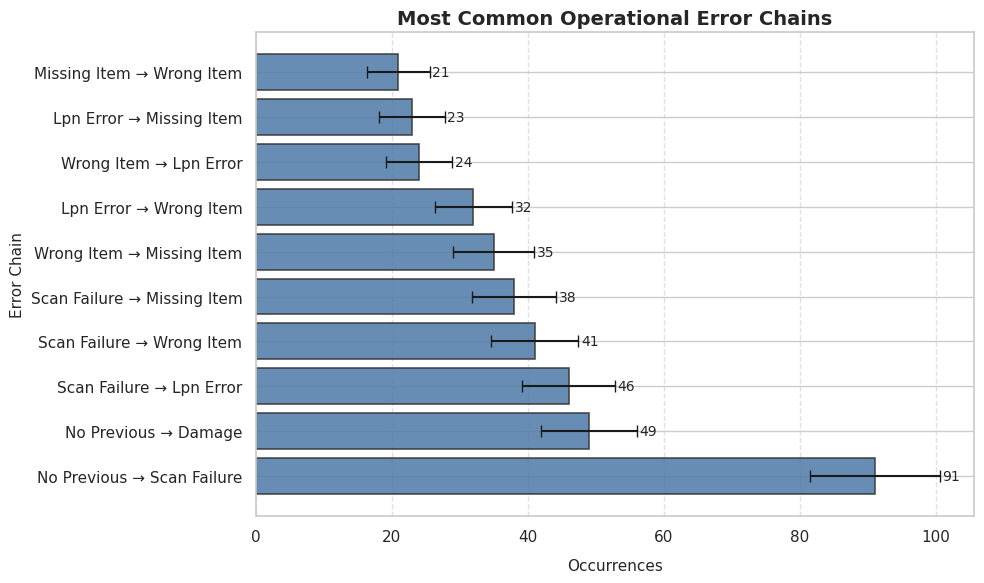

In [13]:
# -----------------------------------------
# Horizontal bar chart of top recurring chains
# -----------------------------------------
# This chart ranks the most common error-to-error sequences.

# Format chain labels for readability
sankey_data["chain"] = (
    sankey_data["previous_error"].str.replace("_", " ").str.title()
    + " → " +
    sankey_data["error_type"].str.replace("_", " ").str.title()
)

values = sankey_data["count"].values
error = np.sqrt(values)  # simple count-based approximation for intervals

plt.figure(figsize=(10, 6))

plt.barh(
    sankey_data["chain"],
    values,
    xerr=error,
    capsize=4,
    color="#4E79A7",
    alpha=0.85,
    edgecolor="#333333",
    linewidth=1.2
)

# Add labels at the end of each bar
for i, v in enumerate(values):
    plt.text(
        v + error[i] + 0.4,
        i,
        str(v),
        va="center",
        fontsize=10
    )

plt.title("Most Common Operational Error Chains", fontsize=14, weight="bold")
plt.xlabel("Occurrences", fontsize=11, labelpad=10)
plt.ylabel("Error Chain", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
transition_matrix = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .unstack(fill_value=0)
)

# Convert to probabilities
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

transition_matrix

# This is real-world operations modeling
# You’re now extracting behavior patterns from data
# This is the foundation of Markov Chains

error_type,damage,lpn_error,missing_item,scan_failure,wrong_item
previous_error,,,,,
lpn_error,0.00,0.00000,0.418182,0.00,0.581818
missing_item,0.00,0.00000,0.000000,0.00,1.000000
no_previous,0.35,0.00000,0.000000,0.65,0.000000
scan_failure,0.00,0.36800,0.304000,0.00,0.328000
wrong_item,0.00,0.40678,0.593220,0.00,0.000000


### Simulate Error Chains (Markov Thinking)

In [15]:
def simulate_chain(start_error, steps=5):
    current = start_error
    chain = [current]

    for _ in range(steps):
        if current not in transition_matrix.index:
            break

        probs = transition_matrix.loc[current]
        next_error = rng.choice(probs.index, p=probs.values)

        chain.append(next_error)
        current = next_error

    return chain

simulate_chain("scan_failure")

# “If this error happens… what tends to happen next?”
# That’s predictive process behavior

['scan_failure',
 np.str_('lpn_error'),
 np.str_('wrong_item'),
 np.str_('missing_item'),
 np.str_('wrong_item'),
 np.str_('lpn_error')]

In [16]:
chain_counts = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

chain_counts.head(10)

# “These are the most common failure sequences in operations.”

,previous_error,error_type,count
4,no_previous,scan_failure,91
3,no_previous,damage,49
5,scan_failure,lpn_error,46
7,scan_failure,wrong_item,41
6,scan_failure,missing_item,38
9,wrong_item,missing_item,35
1,lpn_error,wrong_item,32
8,wrong_item,lpn_error,24
0,lpn_error,missing_item,23
2,missing_item,wrong_item,21


In [17]:
error_impact = {
    "wrong_item": 5,
    "missing_item": 8,
    "lpn_error": 6,
    "scan_failure": 4
}

df["error_cost"] = df["error_type"].map(error_impact)

impact_by_chain = (
    df.groupby(["previous_error", "error_type"])["error_cost"]
    .sum()
    .reset_index()
    .sort_values(by="error_cost", ascending=False)
)

impact_by_chain.head(10)

# “These chains are not just frequent — they are expensive.”

,previous_error,error_type,error_cost
4,no_previous,scan_failure,364.0
6,scan_failure,missing_item,304.0
9,wrong_item,missing_item,280.0
5,scan_failure,lpn_error,276.0
7,scan_failure,wrong_item,205.0
0,lpn_error,missing_item,184.0
1,lpn_error,wrong_item,160.0
8,wrong_item,lpn_error,144.0
2,missing_item,wrong_item,105.0
3,no_previous,damage,0.0


In [18]:
df["risk_score"] = df["error_cost"] + df["previous_error"].map(error_impact).fillna(0)
# rank risky orders
# identify problematic workflows

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Example features
features = ["process_step"]
X = pd.get_dummies(df[features])
y = df["error_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))
# “I can predict operational errors before they happen.”

Accuracy: 0.3625


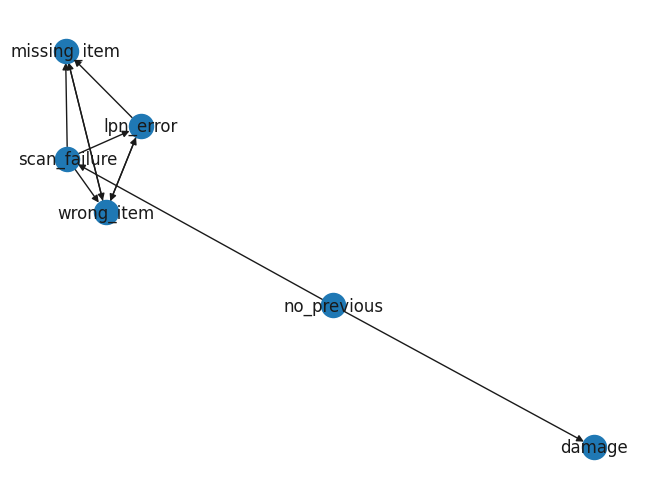

In [20]:
import networkx as nx

G = nx.from_pandas_edgelist(
    chain_counts,
    source="previous_error",
    target="error_type",
    edge_attr="count",
    create_using=nx.DiGraph()
)

nx.draw(G, with_labels=True)

# your system is a failure network


> “I built a system to analyze and model operational error propagation using Python.
I identified high-risk failure chains, quantified their impact, and simulated future error scenarios to support process improvement decisions.”




## Key Insight

The analysis suggests that upstream identification problems,
particularly **barcode scan failures**, frequently trigger
downstream operational issues such as:

- Wrong item selection
- Missing items during packing
- Labeling errors

This indicates that improving **early-stage scanning reliability**
could significantly reduce downstream operational errors.

Potential operational interventions:

• Improve barcode scanning hardware reliability  
• Introduce scan validation checkpoints  
• Provide targeted training for high-error workflow steps  

Reducing upstream scan failures may prevent entire error chains,
improving throughput and operational efficiency.


# Predicting Operational Errors
> “Can we predict which errors are likely to occur based on process conditions?”

In [21]:
# Example features (adapt to your dataset)
features = ["process_step"]
X = pd.get_dummies(df[features])
y = df["error_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.3125


### Model Findings

## Operational Recommendations

Based on the analysis:

1. Scan failures are a major upstream driver of downstream errors.
   → Recommendation: Improve scanning validation systems.

2. Wrong item errors frequently lead to missing item issues.
   → Recommendation: Introduce verification checkpoints during picking.

3. Certain process steps show higher error concentration.
   → Recommendation: Provide targeted training for those stages

> Add blockquote



# Key Takeaways

Title: Key Takeaways

What goes here:

3 to 5 bullets
summary of what the analysis proved
summary of why it *matters*

# Next Steps

What goes here:

use real warehouse data
improve chain modeling
add cost estimates
test recommendations in production
improve predictive features

Why this matters:
This makes you sound like a consultant and strategist, not just a notebook builder.